In [2]:
# Imports #
# Standard Libraries #
import ast
import datetime
import os
from pathlib import Path
import sys

# Third-Party Packages #
import numpy as np
import matplotlib.pyplot as plt
from mxbids import Subject
import pandas as pd
import pickle
import seaborn as sns
from sqlalchemy import select

# Local Packages #

# Definitions #
"""
module_path = Path("/home/akhambhati/Holocron/repos/github.com/khambhati-lab/RNSFeatureExtractionPipeline/src/dataproc").as_posix()
if module_path not in sys.path:
    sys.path.append(module_path)
print(sys.path)
import stimartifact
"""

ROOT_PATH = Path("/home/akhambhati/Holocron/scratch/epilepsy_neuropace_artifacts/")
MXBIDS_PATH = Path("/mnt/hopfield.ucsf.edu/hdd-pool/20_datasets/epilepsy_neuropace")


# Functions #
def get_proxy(subject_id, session_id):
    # Create MXBIDS Subject
    mxbids_subject = Subject(
        name=subject_id,
        parent_path=MXBIDS_PATH,
        load=True,
        load_sessions=True,
        load_modalities=True)

    mxbids_session = mxbids_subject.sessions[session_id]
    cdfs = mxbids_session.modalities["ieeg"].components["cdfs"].get_cdfs()
    proxy = cdfs.components["contents"].require_contents_proxy()
    _ =  cdfs.components["contents"].contents_table.create_session()
        
    return proxy, cdfs


def get_candidate_events(csv):
    with open(csv, "r") as csv_file:
        stims = []
        for entry in csv_file:
            stims.append([*map(int, entry.split("\n")[0].split(','))])
        stims = np.array(stims)
    return stims


def aggregate_events(events, min_interval, max_duration):
    if events.size == 0:
        return events
    
    # 1. Sort by start time to ensure sequential processing
    events = events[events[:, 0].argsort()]
    
    # 2. Find where the gap between consecutive events exceeds min_interval
    # Gap = Start of next event - End of current event
    gaps = events[1:, 0] - events[:-1, 1]
    
    # 3. Identify indices where a new aggregate group should start
    # We always start a new group if the gap > min_interval
    split_indices = np.where(gaps > min_interval)[0] + 1
    
    # 4. Split the array into groups of overlapping/near events
    groups = np.split(events, split_indices)
    
    # 5. For each group, take the earliest start and latest end
    aggregated = np.array([[g[:, 0].min(), g[:, 1].max()] for g in groups])

    # 6. For each aggregated event, discard those exceeding a duration
    aggregated = aggregated[np.diff(aggregated, axis=1)[:,0] <= max_duration]
    
    return aggregated


def sample_events(events, interval_range, duration_range):
    if events.size == 0:
        return events
    
    # 1. Sort by start time to ensure sequential processing
    events = events[events[:, 0].argsort()]
    
    # 2. Find where the gap between consecutive events exceeds min_interval
    # Gap = Start of next event - End of current event
    gaps = events[1:, 0] - events[:-1, 1]

    gaps[:-1], gaps[1:]
    
    # 3. Identify events that fall in interval range
    events = events[1:-1][
        (gaps[:-1] > interval_range[0]) &
        (gaps[:-1] < interval_range[1]) &
        (gaps[1:] > interval_range[0]) & 
        (gaps[1:] < interval_range[1])
    ]

    # 4. Identify events that fall in duration range
    durs = events[:,1]-events[:,0]
    events = events[(durs > duration_range[0]) & (durs < duration_range[1])]

    return events
    
def get_elecs(cdfs):
    contents_table = cdfs.contents_database.tables["contents"]
    
    with contents_table.create_session() as session:
        elecs_entries = session.execute(
            select(
                contents_table.table_schema.start_id,
                contents_table.table_schema.neuropace_ecog_ch1_anode,
                contents_table.table_schema.neuropace_ecog_ch1_cathode,
                contents_table.table_schema.neuropace_ecog_ch2_anode,
                contents_table.table_schema.neuropace_ecog_ch2_cathode,
                contents_table.table_schema.neuropace_ecog_ch3_anode,
                contents_table.table_schema.neuropace_ecog_ch3_cathode,
                contents_table.table_schema.neuropace_ecog_ch4_anode,
                contents_table.table_schema.neuropace_ecog_ch4_cathode
            )
        ).all()

    return elecs_entries
    
def extract_peri_stimulus_interval(
    subject_id,
    session_id,
    artifact_start_time,
    artifact_stop_time,
    peri_interval=(-2,2),
    plot=False,
    proxy=None
):
    if proxy is None:
        proxy, cdfs = get_proxy(subject_id, session_id)

    elecs_all = np.array(get_elecs(cdfs))
    
    stream_ecog = proxy.find_data_slice(
        artifact_start_time/1e9 + peri_interval[0],
        artifact_stop_time/1e9 + peri_interval[1],
        approx=True,
        tails=True
    )
    data = stream_ecog.data[...]
    ts = stream_ecog.axis[:]

    elecs_arr = elecs_all[np.argmin(np.abs(elecs_all[:,0].astype(int) - ts[0]))][1:]
    elecs_arr = [f"{i.decode("utf-8")}-{j.decode("utf-8")}" 
                 for i,j in zip(elecs_arr[1::2], elecs_arr[::2])]

    if plot:
        plt.figure(figsize=(9,4))
        plt.plot(
            (ts-ts[0])/1e9,
            np.arange(0,16,4) + 0.75*((data-data.mean(axis=0)) / data.std(axis=0)),
            color='black'
        )
        plt.yticks(
            np.arange(0,16,4),
            elecs_arr
        )
        plt.axvline(
            (artifact_start_time - ts[0]) / 1e9,
            linestyle='--',
            color='r'
        )
        plt.axvline(
            (artifact_stop_time - ts[0]) / 1e9,
            linestyle='--',
            color='r'
        )
        plt.xlabel("Time (s)")
        plt.title(f"{subject_id}: {session_id}")
        plt.show()

    data = data[
        (ts < artifact_start_time) |
        (ts > artifact_stop_time)
    ]
    ts = ts[
        (ts < artifact_start_time) |
        (ts > artifact_stop_time)
    ]
    
    return data, ts, proxy, elecs_arr

def fix_pseudo_bytes(val):
    # Check if the string starts with the b' prefix
    if isinstance(val, str) and val.startswith("b'") and val.endswith("'"):
        try:
            # Step 1: Convert string "b'text'" -> bytes object b'text'
            byte_obj = ast.literal_eval(val)
            # Step 2: Decode bytes -> regular string "text"
            return byte_obj.decode('utf-8')
        except (ValueError, SyntaxError):
            return val
    return val

# Apply the fix
#s_fixed = df_rns_electrode_lut["lead_id"].apply(fix_pseudo_bytes)

['/home/akhambhati/.local/share/uv/python/cpython-3.13.1-linux-x86_64-gnu/lib/python313.zip', '/home/akhambhati/.local/share/uv/python/cpython-3.13.1-linux-x86_64-gnu/lib/python3.13', '/home/akhambhati/.local/share/uv/python/cpython-3.13.1-linux-x86_64-gnu/lib/python3.13/lib-dynload', '', '/home/akhambhati/.cache/uv/archive-v0/V3Nd44FuGq2r36RBBTZr8/lib/python3.13/site-packages', '/home/akhambhati/Holocron/repos/github.com/khambhati-lab/python-neuropacetools/.venv/lib/python3.13/site-packages', '/home/akhambhati/Holocron/repos/github.com/khambhati-lab/python-neuropacetools/src', '/home/akhambhati/Holocron/repos/github.com/khambhati-lab/RNSFeatureExtractionPipeline/src/dataproc']


# Plot Example Stimulation Events

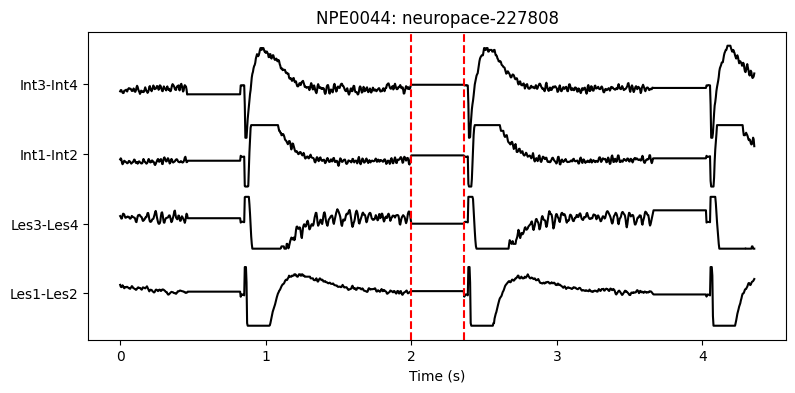

In [4]:
csv = np.random.permutation([*ROOT_PATH.glob("*.csv")])[0]
subject_id = csv.parts[-1].split('_')[0].split('sub-')[-1]
session_id = csv.parts[-1].split('_')[1]

stims = get_candidate_events(csv)
stims = aggregate_events(stims, min_interval=0.5*1e9, max_duration=6*1e9)
stim = np.random.permutation(stims)[0]

for stim in np.random.permutation(stims)[:10]:
    data, ts, proxy, cdfs = extract_peri_stimulus_interval(
        subject_id,
        session_id,
        stim[0],
        stim[1],
        peri_interval=(-2,2),
        plot=True
    )
    break

# Stimulation Event Statistics (Population)

In [ ]:
event_durs = []
event_ibi = []
for csv in [*ROOT_PATH.glob("*.csv")]:
    stims = get_candidate_events(csv)
    stims = aggregate_events(stims, min_interval=0.5*1e9, max_duration=6.0*1e9)
    if stims.shape[0] < 2:
        continue
        
    for stim in stims:
        event_durs.append((stim[1]-stim[0]) / 1e9)

    for first_end, next_start in zip(stims[:-1, 1], stims[1:, 0]):
        event_ibi.append((next_start-first_end) / 1e9)
event_durs = np.array(event_durs)
event_ibi = np.array(event_ibi)

In [ ]:
plt.figure(figsize=(9,4))
plt.hist(np.log10(event_durs), 50);
plt.xticks([np.log10(0.1), np.log10(0.25), np.log10(0.5), np.log10(1.0), np.log10(5)],
           [0.1, 0.25, 0.5, 1.0, 5.0])
plt.xlabel("Duration of Detected Stimulation Events (s)")
plt.ylabel("Number of Detected Events")
plt.title(f"Total Events: {len(event_durs)}, Number of Patients: {len(np.unique([csv.parts[-1].split('_')[0].split('sub-')[-1] for csv in [*ROOT_PATH.glob("*.csv")]]))}")
plt.show()



plt.figure(figsize=(9,4))
plt.hist(np.log10(event_ibi[(event_ibi >= 1/250) & ((event_ibi <= 3600*24*7))]), 50);
plt.xticks([np.log10(0.5), np.log10(1.0), np.log10(5), np.log10(10), np.log10(60), np.log10(600), np.log10(3600), np.log10(3600*24), np.log10(3600*24*7)],
           [0.5, 1, 5, 10, 60, 600, 3600, 3600*24, 3600*24*7])
plt.xlabel("Interval between Detected Stimulation Events (s)")
plt.ylabel("Number of Detected Events")
plt.title(f"Total Events: {len(event_durs)}, Number of Patients: {len(np.unique([csv.parts[-1].split('_')[0].split('sub-')[-1] for csv in [*ROOT_PATH.glob("*.csv")]]))}")
plt.axvline(np.log10(2.0), color='r', linestyle='--', linewidth=2.0)
plt.show()

# Example Stimulation Data from Random Patient

In [ ]:
agg_min_interval = 0.5
agg_max_duration = 6
peri_stim_interval = (-2,2)
fs = 250
event_dur = ((peri_stim_interval[1] - peri_stim_interval[0]) * fs) - 1
#####
#####

#csv = [*ROOT_PATH.glob("*.csv")][-20] #np.random.permutation([*ROOT_PATH.glob("*.csv")])[0]
csv = [*ROOT_PATH.glob("sub-NPE0007*.csv")][0]
subject_id = csv.parts[-1].split('_')[0].split('sub-')[-1]
session_id = csv.parts[-1].split('_')[1]

stims = get_candidate_events(csv)
stims = aggregate_events(
    stims,
    min_interval=agg_min_interval*1e9,
    max_duration=agg_max_duration*1e9
)
stims_isolated = sample_events(
    stims,
    interval_range=(peri_stim_interval[1]*1e9, np.inf),
    duration_range=(-np.inf, np.inf)
)

print(stims.shape, stims_isolated.shape)

all_data = []
all_ts = []
for ev_ii, event in enumerate(stims_isolated[:]):
    data, ts, _ = extract_peri_stimulus_interval(
        subject_id,
        session_id,
        event[0],
        event[1],
        peri_interval=peri_stim_interval,
        plot=False,
        proxy=None
    )
    all_data.append(data)
    all_ts.append(ts)

    print(f"{ev_ii+1} / {stims_isolated.shape[0]}  ---- {len(ts)}")
all_data = np.array([data for data in all_data if data.shape[0] == event_dur])
all_ts = np.array([ts for ts in all_ts if ts.shape[0] == event_dur])

In [ ]:
mu, sd = all_data[:,:(peri_stim_interval[1]*fs)-int(0.01*fs),:].mean(axis=1), all_data[:,:(peri_stim_interval[1]*fs)-int(0.01*fs),:].std(axis=1)
all_data_zs = ((all_data.transpose((1,0,2)) - mu) / sd).transpose((1,0,2))

vmin, vmax = (0.99*(-1*(np.abs(all_data_zs).max())), 0.99*np.abs(all_data_zs).max())
for ch in range(4):
    print(f"Channel: {ch}")
    plt.figure(figsize=(6,9))
    ax = plt.subplot(111)
    ax = sns.heatmap(
        pd.DataFrame(all_data_zs[:,:,ch], columns=((all_ts[0,:] - all_ts[0,0]) / 1e9)-2),
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        cbar_kws={"label": "icEEG Voltage (z.s.)"}
    )
    ax.set_xticks([0, 250, 500, 750, 1000], labels=[-2.0,-1.0,0.0,1.0,2.0])
    
    seconds_elapsed = ((all_ts[:,0]  - all_ts[0,0]) / 1e9)
    months_elapsed = seconds_elapsed / (3600*24*30)
    month_lbl, month_idx = np.unique(np.round(months_elapsed), return_index=True)
    month_lbl = month_lbl[::4]
    month_idx = month_idx[::4]
    ax.set_yticks(month_idx, month_lbl.astype(int))
    ax.set_ylabel("Time elapsed since implant (months)")
    ax.set_xlabel("Time rel. Stimulation (s)")
    ax.set_title("Single-Trial Responses")
    ax.grid(True, linestyle="--", color=(0.75,0.75,0.75))
    plt.show()

    plt.figure()
    ax = plt.subplot(111)
    ax.plot(np.arange(999) / 250 - 2 , all_data_zs[:,:,ch].T, color='k', alpha=0.25, linewidth=0.1);
    ax.plot(np.arange(999) / 250 - 2, all_data_zs[:,:,ch].mean(axis=0), color='r', alpha=1.0, linewidth=1.0);
    ax.set_ylim([-80,80])
    ax.set_xlabel("Time rel. Stimulation (s)")
    ax.set_ylabel("icEEG Voltage (z.s.)")
    ax.set_title(f"{subject_id}_{session_id}")
    plt.show()

# Bootstrap PCA

In [2]:
import numpy as np

class IncrementalPCACov:
    """
    Pure NumPy minibatch PCA via running mean + covariance accumulation.

    Parameters
    ----------
    n_components : int
        Number of PCs to keep when finalized.
    dtype : np.dtype
        Internal floating dtype.
    """
    def __init__(self, n_components, dtype=np.float64):
        self.n_components = int(n_components)
        self.dtype = dtype

        self.n_samples_seen_ = 0
        self.mean_ = None
        self.M2_ = None   # sum of outer products about the running mean

        self.components_ = None
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None

    def partial_fit(self, X):
        """
        Update running mean and covariance statistics from a minibatch.

        Parameters
        ----------
        X : ndarray, shape (batch_size, n_features)
        """
        X = np.asarray(X, dtype=self.dtype)
        if X.ndim != 2:
            raise ValueError("X must be 2D: (n_samples, n_features)")

        nb, d = X.shape
        if nb == 0:
            return self

        batch_mean = X.mean(axis=0)

        # Within-batch scatter about batch mean
        Xc = X - batch_mean
        batch_M2 = Xc.T @ Xc

        if self.n_samples_seen_ == 0:
            self.n_samples_seen_ = nb
            self.mean_ = batch_mean.copy()
            self.M2_ = batch_M2.copy()
            return self

        na = self.n_samples_seen_
        mean_a = self.mean_
        M2_a = self.M2_

        delta = batch_mean - mean_a
        n = na + nb

        # Merge two groups' covariance statistics
        new_mean = mean_a + delta * (nb / n)
        new_M2 = M2_a + batch_M2 + np.outer(delta, delta) * (na * nb / n)

        self.n_samples_seen_ = n
        self.mean_ = new_mean
        self.M2_ = new_M2
        return self

    def finalize(self):
        """
        Compute PCA from accumulated statistics.
        """
        if self.n_samples_seen_ < 2:
            raise ValueError("Need at least 2 samples to finalize PCA")

        cov = self.M2_ / (self.n_samples_seen_ - 1)

        evals, evecs = np.linalg.eigh(cov)
        order = np.argsort(evals)[::-1]

        evals = evals[order]
        evecs = evecs[:, order]

        k = min(self.n_components, evecs.shape[1])

        self.components_ = evecs[:, :k].T
        self.explained_variance_ = evals[:k]

        total_var = np.sum(evals)
        if total_var > 0:
            self.explained_variance_ratio_ = evals[:k] / total_var
        else:
            self.explained_variance_ratio_ = np.zeros(k, dtype=self.dtype)

        return self

    def transform(self, X):
        """
        Project data into PC space.

        Parameters
        ----------
        X : ndarray, shape (n_samples, n_features)

        Returns
        -------
        Z : ndarray, shape (n_samples, n_components)
        """
        if self.components_ is None:
            raise ValueError("Call finalize() before transform()")

        X = np.asarray(X, dtype=self.dtype)
        return (X - self.mean_) @ self.components_.T

    def inverse_transform(self, Z, c_array=None):
        """
        Reconstruct from PC scores.
        """
        if self.components_ is None:
            raise ValueError("Call finalize() before inverse_transform()")

        if c_array is None:
            c_array = np.arange(self.n_components)

        Z = np.asarray(Z, dtype=self.dtype)
        return Z[:,c_array] @ self.components_[c_array] + self.mean_

In [3]:
agg_min_interval = 0.5
agg_max_duration = 6
peri_stim_interval = (-2,2)
fs = 250
event_dur = ((peri_stim_interval[1] - peri_stim_interval[0]) * fs) - 1
#####
#####

full_stim_catalog = {}
for csv in [*ROOT_PATH.glob("*.csv")]:
    subject_id = csv.parts[-1].split('_')[0].split('sub-')[-1]
    session_id = csv.parts[-1].split('_')[1]

    stims = get_candidate_events(csv)
    stims = aggregate_events(
        stims,
        min_interval=agg_min_interval*1e9,
        max_duration=agg_max_duration*1e9
    )
    stims_isolated = sample_events(
        stims,
        interval_range=(peri_stim_interval[1]*1e9, np.inf),
        duration_range=(-np.inf, np.inf)
    )
    full_stim_catalog[f"{subject_id}_{session_id}"] = (subject_id, session_id, stims_isolated)

In [ ]:
def construct_minibatch(
    full_stim_catalog,
    mb_size
):
    all_data = []
    mb_i  = 0
    while mb_i < mb_size:
        key = np.random.permutation([*full_stim_catalog.keys()])[0]
        subject_id,  session_id, stims_isolated = full_stim_catalog[key]
        if stims_isolated.shape[0] == 0:
            continue
        event = np.random.permutation(stims_isolated)[0]
        try:
            data, ts, _ = extract_peri_stimulus_interval(
                subject_id,
                session_id,
                event[0],
                event[1],
                peri_interval=peri_stim_interval,
                plot=False,
                proxy=None
            )
        except:
            continue
        if data.shape[0] == event_dur:
            for datum in data.T:
                mu, sd = datum[:(peri_stim_interval[1]*fs)-int(0.01*fs)].mean(), datum[:(peri_stim_interval[1]*fs)-int(0.01*fs)].std()
                datum = (datum - mu) / sd
                all_data.append(datum)
            mb_i += 1
    return np.array(all_data)


def get_PC_scores(
    full_stim_catalog,
    catalog_key,
    ipca
):

    subject_id, session_id, stims_isolated = full_stim_catalog[catalog_key]
    if stims_isolated.shape[0] == 0:
        return np.zeros((0, ipca.n_components)), np.zeros((0, 2))

    proxy = None
    pc_scores = []
    pc_events = []
    pc_rsqfit = []
    for event_ii, event in enumerate(stims_isolated):    
        #print(f"{subject_id} - {session_id} - {event_ii+1} / {len(stims_isolated)}")
        try:
            data, ts, proxy = extract_peri_stimulus_interval(
                subject_id,
                session_id,
                event[0],
                event[1],
                peri_interval=peri_stim_interval,
                plot=False,
                proxy=proxy
            )
        except:
            continue
        if data.shape[0] == event_dur:
            for datum in data.T:
                mu, sd = datum[:(peri_stim_interval[1]*fs)-int(0.01*fs)].mean(), datum[:(peri_stim_interval[1]*fs)-int(0.01*fs)].std()
                datum = (datum - mu) / sd
                datum_pc = ipca.transform(datum)

                rsq = []
                for nc in range(1, ipca.n_components+1): 
                    recon = datum_pc[:nc] @ ipca.components_[:nc]
                    total_ssq = np.sum((datum - datum.mean())**2)
                    error_ssq = np.sum((datum - recon)**2)
                    r2 = 1 - error_ssq / total_ssq
                    rsq.append(r2)
                
                pc_scores.append(datum_pc)
                pc_events.append(event)
                pc_rsqfit.append(rsq)
    proxy.close()

    np.savez(
        f"ipca_scores-{subject_id}_{session_id}.npz",
        pc_scores=np.array(pc_scores),
        pc_events=np.array(pc_events),
        pc_rsqfit=np.array(pc_rsqfit)
    )

## TRAIN MODEL ON RANDOM MINIBATCH

In [ ]:
with open(f"ipca_checkpoint-{999}.pkl", "rb") as f:
    ipca = pickle.load(f)
ipca.finalize()

In [ ]:
plt.figure(figsize=(12,9))
for i in range(ipca.n_components):
    ax = plt.subplot(8,8,i+1)
    ax.plot(
        np.linspace(-2,2,999),
        ipca.components_[i],
        linewidth=1.0,
        color='k'
    )
    ax.axvline(0, color='r', linewidth=0.5)
    ax.set_ylim([-0.25, 0.25])
    ax.set_title(f"PC-{i+1}", fontsize=8)
    ax.set_axis_off()
plt.show()

# GET ALL PC SCORES

In [ ]:
from multiprocessing import Pool
pool = Pool(32)

inputs = [(full_stim_catalog, catalog_key, ipca) for catalog_key in full_stim_catalog]
pool.starmap(get_PC_scores, inputs)

## R2 on pre/post windows

In [6]:
data = pd.read_pickle("ipca_scores.pkl")

NameError: name 'pd' is not defined

In [ ]:
r2 = data.groupby(["Subject_ID", "Session_ID"]).mean().reset_index().iloc[:, -64:]

In [ ]:
mu, sd = r2.mean(axis=0), r2.sem(axis=0)

plt.figure(figsize=(9,9))
ax = plt.subplot(111)
ax.plot(np.arange(1,65), mu, color='k')
ax.fill_between(np.arange(1,65), mu-sd, mu+sd, color='k', alpha=0.1)
ax.set_ylim([0,1])
ax.set_xlim([0, 65])
ax.set_xticks(np.arange(1,67,3))
ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("Single-trial Goodness-of-fit ($R^2$)")
ax.grid(True, linestyle='--')

In [ ]:
sub_sampled = data.sample(frac=0.01)

In [ ]:
from umap import UMAP
fit = UMAP(
    n_neighbors=10,
    min_dist=0.2,
    n_components=2,
    metric="euclidean",
    n_jobs=32
)
%time u = fit.fit_transform(sub_sampled.iloc[:, 4:14].values)

In [ ]:
plt.figure(figsize=(8,8), dpi=300)
ax = plt.subplot(111)
ax.scatter(u[:,0], u[:,1], s=0.1, alpha=0.05, color='k')
ax.set_axis_off()
plt.show()

In [ ]:
def get_range(x):
    sel_outcome = df_outcome[df_outcome["npe_code"] == x["Subject_ID"]]
    if sel_outcome.shape[0] == 0:
        return np.nan
    sel_outcome = sel_outcome.loc[(sel_outcome["visit_date_clinician_DEIDENT"] - x["Stim_Start"]).abs().idxmin()]
    return (sel_outcome["clin_sz_freq"] - sel_outcome["seizure_frequency"]) / sel_outcome["seizure_frequency"]

pct_change_clin_sz_freq = sub_sampled.apply(get_range, axis=1)

In [ ]:
from sklearn.linear_model import LinearRegression

y = pct_change_clin_sz_freq.dropna().copy()
X = sub_sampled.loc[y.index].iloc[:,4:68]
model = LinearRegression().fit(X, y)
model.score(X,y)

In [ ]:
from sklearn.cluster import KMeans
km = KMeans(25)
C = km.fit(sub_sampled.iloc[:,4:68]).predict(sub_sampled.iloc[:,4:68])
C.min(), C.max()

In [ ]:
import matplotlib.colors as mcolors
vmin = C.min()
vmax = C.max()
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

plt.figure(figsize=(4,4), dpi=300)
ax = plt.subplot(111)
scatter = ax.scatter(
    u[:,0], u[:,1],
    s=0.2, alpha=1.0,
    cmap='Spectral_r',
    norm=norm,
    edgecolors='none',
    c=C
)
ax.set_axis_off()
plt.show()

plt.figure(figsize=(4,4), dpi=300)
for c in np.unique(C):
    ax = plt.subplot(5,5,c+1)
    ax.plot(
        (sub_sampled.iloc[C==c,4:68] @ ipca.components_).mean(),
        c=plt.cm.Spectral_r((c+1)/len(np.unique(C))),
        linewidth=1.0,
    )
    ax.set_axis_off()
plt.show()

In [ ]:
import matplotlib.colors as mcolors
vmin = -1
vmax = 0
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

plt.figure(figsize=(8,8), dpi=300)
ax = plt.subplot(111)
scatter = ax.scatter(
    u[:,0], u[:,1],
    s=0.1, alpha=0.1,
    cmap='RdBu_r',
    norm=norm,
    #edgecolors='none',
    c=pct_change_clin_sz_freq.values
)
#cbar = plt.colorbar(scatter)
#cbar.ax.set_ylabel("Pct. Seizure Reduction from Baseline")
ax.set_axis_off()
plt.show()

In [ ]:
sub_sampled.iloc[np.flatnonzero(u[:,0] > 11)]["Subject_ID"].unique()

In [ ]:
from sklearn.linear_model import LinearRegression

y = pct_change_clin_sz_freq.dropna().copy()
X = np.abs(sub_sampled.loc[y.index].iloc[:,4:68])
model = LinearRegression().fit(X, y)
model.score(X,y)

# Stimulation Parameters

In [2]:
df_registry = pd.read_csv("/mnt/epilepsy_neuropace/registry/pdms_to_npe.csv")
df_registry["date_of_birth"] = pd.to_datetime(df_registry["date_of_birth"])


df_outcome = pd.read_csv("/mnt/epilepsy_neuropace/registry/pdms_to_outcomes.csv")
df_outcome["visit_date_clinician"] = pd.to_datetime(df_outcome["visit_date_clinician"])

df_outcome["visit_date_clinician_DEIDENT"] = None
df_outcome["npe_code"] = None
for sel in df_outcome.iterrows():
    try:
        dob = df_registry.loc[df_registry["pdms_id"].astype(str).apply(lambda x: str(sel[1]["pdms_id"]) in x)]["date_of_birth"].iloc[0]
        npe = df_registry.loc[df_registry["pdms_id"].astype(str).apply(lambda x: str(sel[1]["pdms_id"]) in x)]["npe_code"].iloc[0]
        dob_deident = int((sel[1]["visit_date_clinician"] - dob).total_seconds() * 1e9)
        df_outcome.loc[sel[0], "visit_date_clinician_DEIDENT"] = dob_deident
        df_outcome.loc[sel[0], "npe_code"] = npe
    except:
        continue
df_outcome = df_outcome.dropna()

NameError: name 'pd' is not defined

In [ ]:
df_registry

In [ ]:
import pandas as pd
from glob import glob

stim_parameters = {}
for pfile in glob("/media/jaspernas/root_store/RNS-subjects/Programming_Epochs/*.csv"): 
    npe_code = pfile.split("/")[-1].split(" ")[0]
    dob = df_registry[df_registry["npe_code"] == npe_code]["date_of_birth"].iloc[0]
    
    csv = pd.read_csv(pfile).iloc[:, 1:]
    csv["Programming_Date"] = csv["Programming_Date"].apply(pd.to_datetime)
    csv["Programming_Date_DEIDENT"] = ((csv["Programming_Date"] - dob).dt.total_seconds() * 1e9).astype(np.uint64)
    stim_parameters[npe_code] = csv

In [ ]:
corr_R2 = []
for npe_code in data["Subject_ID"].unique():
    print(npe_code)
    if npe_code not in stim_parameters:
        continue

    sel_data = data[data["Subject_ID"] == npe_code]    
    data_stim_parameters = []
    for datum in sel_data.iterrows():
        sel_stim_parameters = stim_parameters[datum[1]["Subject_ID"]]
        stim_idx = (datum[1]["Stim_Start"] - sel_stim_parameters["Programming_Date_DEIDENT"]).idxmin()
        data_stim_parameters.append(sel_stim_parameters.iloc[stim_idx])
    data_stim_parameters = pd.concat(data_stim_parameters, axis=1).T

    R2 = []
    for metric in [["Tx1Br1-Charge_Density"]]: #, "Tx1Br1-Frequency", "Tx1Br2-Charge_Density", "Tx1Br2-Frequency"]
        if data_stim_parameters[metric].astype(float).iloc[np.flatnonzero(~data_stim_parameters[metric].astype(float).isna().any(axis=1))].shape[0] < 3:
            continue
        for i in range(64):
            lr = LinearRegression()
            lr.fit(
                data_stim_parameters[metric].astype(float).iloc[np.flatnonzero(~data_stim_parameters[metric].astype(float).isna().any(axis=1))],
                sel_data[f"pc-{i+1}"].iloc[np.flatnonzero(~data_stim_parameters[metric].astype(float).isna().any(axis=1))]
            )
            R2.append(
                lr.score(
                    data_stim_parameters[metric].astype(float).iloc[np.flatnonzero(~data_stim_parameters[metric].astype(float).isna().any(axis=1))],
                    sel_data[f"pc-{i+1}"].iloc[np.flatnonzero(~data_stim_parameters[metric].astype(float).isna().any(axis=1))]
                )
            )
    corr_R2.append(R2)

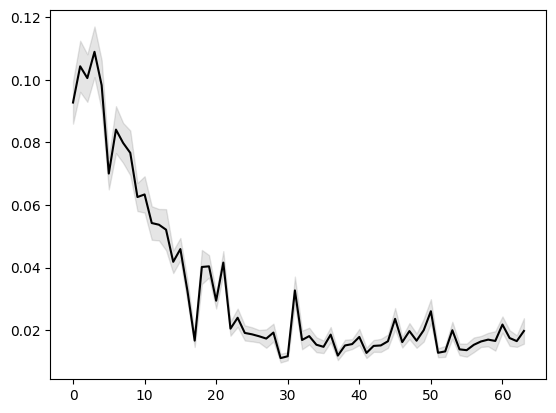

In [162]:
mu = np.array([np.sqrt(R2) for R2 in corr_R2 if (len(R2) == 64) & (np.sum(R2) > 0)]).mean(axis=0)
std = np.array([np.sqrt(R2) for R2 in corr_R2 if (len(R2) == 64) & (np.sum(R2) > 0)]).std(axis=0) / np.sqrt(114)

plt.plot(np.arange(64), mu, color='k')
plt.fill_between(np.arange(64), mu-std, mu+std, color='k', alpha=0.1)

In [ ]:
from sklearn.linear_model import LinearRegression
metric = ["Tx1Br1-Charge_Density", "Tx1Br1-Frequency", "Tx1Br2-Charge_Density", "Tx1Br2-Frequency"]

corr = []
for i in range(64):
    lr = LinearRegression()
    lr.fit(
        data_stim_parameters[metric].astype(float).iloc[np.flatnonzero(~data_stim_parameters[metric].astype(float).isna().any(axis=1))],
        sel_data[f"pc-{i+1}"].iloc[np.flatnonzero(~data_stim_parameters[metric].astype(float).isna().any(axis=1))]
    )
    corr.append(
        lr.score(
            data_stim_parameters[metric].astype(float).iloc[np.flatnonzero(~data_stim_parameters[metric].astype(float).isna().any(axis=1))],
            sel_data[f"pc-{i+1}"].iloc[np.flatnonzero(~data_stim_parameters[metric].astype(float).isna().any(axis=1))]
        )
    )    

plt.plot(np.sqrt(np.array(corr)))

In [ ]:
from scipy.stats import pearsonr

In [ ]:
csv["Programming_Date_DEIDENT"]

In [ ]:
data[data["Subject_ID"] == "NPE0039"].apply(lambda x: (x["Stim_Start"] - csv["Programming_Date_DEIDENT"])

In [ ]:
X = sub_sampled.loc[pct_change_clin_sz_freq.dropna().index]

In [ ]:
X["pct_seizure_reduction"] = pct_change_clin_sz_freq.dropna().values.clip(min=-1,max=0)

In [ ]:
for i in range(64):
    plt.hist(X.groupby("Subject_ID")[["pct_seizure_reduction", f"pc-{i+1}"]].corr().reset_index().iloc[::2][f"pc-{i+1}"].dropna())
    plt.title(
        ttest_1samp(X.groupby("Subject_ID")[["pct_seizure_reduction", f"pc-{i+1}"]].corr().reset_index().iloc[::2][f"pc-{i+1}"].dropna(), 0)
    )
    plt.show()
    print(i)

In [ ]:
for i in range(64):
    print(i, pearsonr(X[f"pc-{i+1}"].abs(), X["pct_seizure_reduction"]))

In [ ]:
from scipy.stats import ttest_1samp

In [ ]:
data

In [519]:
sel_data = data[data["Subject_ID"] == "NPE0004"]    
sel_data2 = sel_data.iloc[0::4]
sel_data2["Timestamp"] = pd.to_datetime(sel_data2["Stim_Start"])
sel_data2["CircTime"] = sel_data2["Timestamp"].apply(lambda x: (3600*x.hour + 60*x.minute + x.second) / (3600))
PC_scores = sel_data2.iloc[:, 4:68]

/tmp/ipykernel_40253/2297669873.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sel_data2["Timestamp"] = pd.to_datetime(sel_data2["Stim_Start"])
/tmp/ipykernel_40253/2297669873.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sel_data2["CircTime"] = sel_data2["Timestamp"].apply(lambda x: (3600*x.hour + 60*x.minute + x.second) / (3600))


In [520]:
import numpy as np

def fit_pc_cosinor(Z, time_hours):
    """
    Fit multivariate cosinor model:
        Z ~ sin(theta) + cos(theta) + intercept

    Parameters
    ----------
    Z : ndarray, shape (N, K)
        PC scores
    time_hours : ndarray, shape (N,)
        Time of day in [0, 24)

    Returns
    -------
    model : dict
        Contains intercept, beta_sin, beta_cos
    """
    theta = 2 * np.pi * (time_hours / 24.0)

    X = np.column_stack([
        np.ones_like(theta),
        np.sin(theta),
        np.cos(theta),
    ])  # (N, 3)

    # Solve least squares for all PCs at once
    # B shape: (3, K)
    B, _, _, _ = np.linalg.lstsq(X, Z, rcond=None)

    return {
        "intercept": B[0],   # shape (K,)
        "beta_sin": B[1],    # shape (K,)
        "beta_cos": B[2],    # shape (K,)
    }


def predict_pc_scores_from_time(time_hours, model):
    """
    Predict expected PC score vector at each time of day.
    """
    theta = 2 * np.pi * (np.asarray(time_hours) / 24.0)
    intercept = model["intercept"][None, :]
    beta_sin = model["beta_sin"][None, :]
    beta_cos = model["beta_cos"][None, :]

    Zhat = (
        intercept
        + np.sin(theta)[:, None] * beta_sin
        + np.cos(theta)[:, None] * beta_cos
    )
    return Zhat


def reconstruct_waveform_from_pcs(Zhat, mean_waveform, components):
    """
    Reconstruct waveform(s) from PC scores.

    Parameters
    ----------
    Zhat : ndarray, shape (M, K)
        Predicted PC scores
    mean_waveform : ndarray, shape (T,)
    components : ndarray, shape (K, T)

    Returns
    -------
    Xhat : ndarray, shape (M, T)
    """
    return mean_waveform[None, :] + Zhat @ components


def reconstruct_circadian_modulation(time_hours, model, components):
    """
    Reconstruct ONLY the circadian fluctuation component, without mean waveform.
    """
    theta = 2 * np.pi * (np.asarray(time_hours) / 24.0)
    beta_sin = model["beta_sin"][None, :]
    beta_cos = model["beta_cos"][None, :]

    Zcirc = (
        np.sin(theta)[:, None] * beta_sin
        + np.cos(theta)[:, None] * beta_cos
    )

    return Zcirc @ components

def multivariate_cosinor_r2(Z, time_hours, model):
    Zhat = predict_pc_scores_from_time(time_hours, model)

    ss_res = np.sum((Z - Zhat) ** 2)
    ss_tot = np.sum((Z - Z.mean(axis=0, keepdims=True)) ** 2)
    R2_tot = 1 - ss_res / ss_tot

    ss_res = np.sum((Z - Zhat)**2, axis=0)
    ss_tot = np.sum((Z - Z.mean(axis=0))**2, axis=0)
    R2_pcs = 1 - ss_res/ss_tot
    
    return R2_tot, R2_pcs

0.006537024503285416


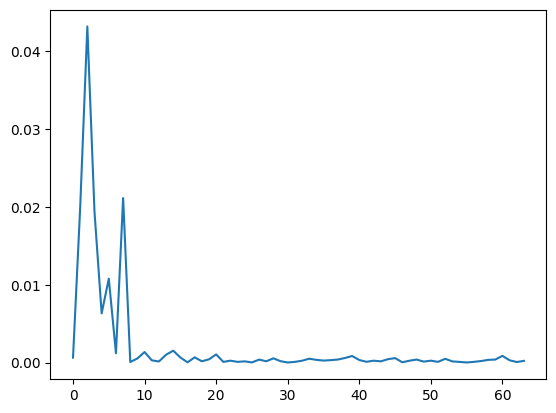

In [521]:
# Fit circadian model in PC space
circ_model = fit_pc_cosinor(PC_scores, sel_data2["CircTime"])

# Predict expected PC scores at selected times
times_eval = np.arange(0, 24, 0.1)  # midnight, 6AM, noon, 6PM
Zhat = predict_pc_scores_from_time(times_eval, circ_model)

# Reconstruct expected full waveforms
waveforms_hat = reconstruct_waveform_from_pcs(
    Zhat,
    mean_waveform=ipca.mean_,
    components=ipca.components_,
)

# Reconstruct circadian modulation only
delta_waveforms = reconstruct_circadian_modulation(
    times_eval,
    circ_model,
    components=ipca.components_,
)

R2_tot, R2_pcs = multivariate_cosinor_r2(PC_scores.values, sel_data2["CircTime"].values, circ_model)
print(R2_tot)
plt.plot(R2_pcs);
plt.show()

In [548]:
Zhat, times_eval

(array([[ 1.52647642e+00, -2.19845244e-01, -4.25775340e+00, ...,
         -1.02299671e-03,  1.62715182e-02,  3.84888306e-02],
        [ 1.54073290e+00, -1.96943981e-01, -4.22796269e+00, ...,
         -1.57442410e-03,  1.59439983e-02,  3.81001516e-02],
        [ 1.55486079e+00, -1.73123341e-01, -4.19691929e+00, ...,
         -2.10071023e-03,  1.56038868e-02,  3.76841924e-02],
        ...,
        [ 1.48303349e+00, -2.82879030e-01, -4.33940957e+00, ...,
          7.78269205e-04,  1.71763281e-02,  3.94886177e-02],
        [ 1.49761682e+00, -2.62827498e-01, -4.31349594e+00, ...,
          1.53753185e-04,  1.68878943e-02,  3.91833017e-02],
        [ 1.51210111e+00, -2.41811435e-01, -4.28627100e+00, ...,
         -4.46805984e-04,  1.65862221e-02,  3.88499632e-02]],
       shape=(240, 64)),
 array([ 0. ,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ,
         1.1,  1.2,  1.3,  1.4,  1.5,  1.6,  1.7,  1.8,  1.9,  2. ,  2.1,
         2.2,  2.3,  2.4,  2.5,  2.6,  2.7,  2.8,  2.9,  

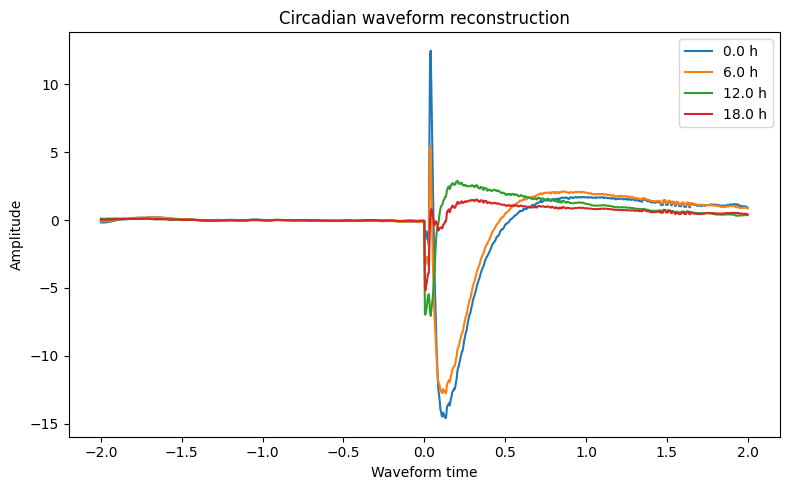

In [475]:
import matplotlib.pyplot as plt

def plot_circadian_waveforms(times_eval, waveforms_hat, time_axis=None, title="Circadian waveform reconstruction"):
    plt.figure(figsize=(8, 5))

    x = np.arange(waveforms_hat.shape[1]) if time_axis is None else time_axis

    for t, w in zip(times_eval, waveforms_hat):
        plt.plot(x, w, label=f"{t:.1f} h")

    plt.xlabel("Waveform time")
    plt.ylabel("Amplitude")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()
plot_circadian_waveforms(times_eval, waveforms_hat, time_axis=np.linspace(-2,2,999))

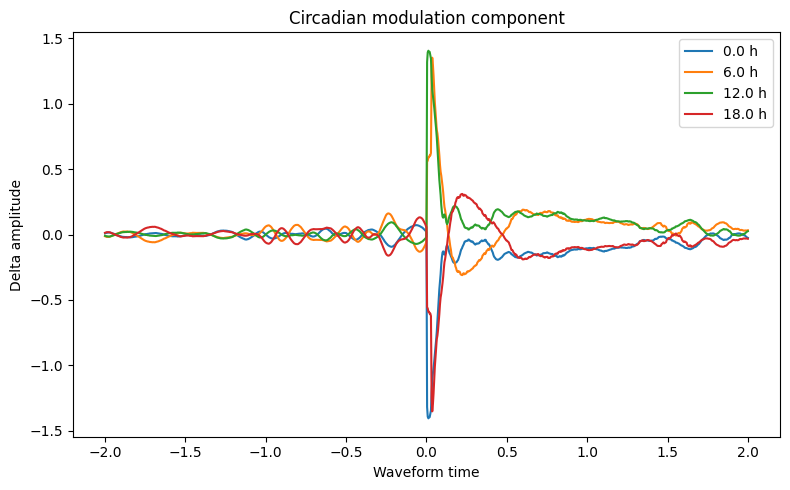

In [467]:
def plot_circadian_modulation(times_eval, delta_waveforms, time_axis=None, title="Circadian modulation component"):
    plt.figure(figsize=(8, 5))

    x = np.arange(delta_waveforms.shape[1]) if time_axis is None else time_axis

    for t, w in zip(times_eval, delta_waveforms):
        plt.plot(x, w, label=f"{t:.1f} h")

    plt.xlabel("Waveform time")
    plt.ylabel("Delta amplitude")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()
plot_circadian_modulation(times_eval, delta_waveforms, time_axis=np.linspace(-2,2,999))